In [4]:
import pandas as pd
import numpy as np
import kagglehub

# 🏗️ STEEL PLATE DEFECT PREDICTION — TAM PROJE DOKÜMANTASYONU

**Proje Adı:** Çelik Levha Kusur Tespit ve Sınıflandırma Sistemi

**Sorumlu Mühendis:** Serdar Önal

**Tarih:** 03.05.2026

**Hedef:** AI ve Veri Bilimi Müfredatı Final Projesi

**Model Türü:** Çok Sınıflı Sınıflandırma (Multi-Class Classification)

**Ana Algoritma:** Optimize Edilmiş XGBoost Classifier


---

# 📌 ÜST RAPOR (EXECUTIVE SUMMARY)

## 🎯 Proje Amacı

Bu proje, endüstriyel üretim hatlarında çelik levhalar üzerindeki yüzey kusurlarını yüksek doğrulukla tespit ederek kalite kontrol süreçlerini otomatikleştirmek amacıyla geliştirilmiştir.

## 🏆 Nihai Başarı Göstergeleri

* **Genel Kaggle Skoru (AUC-ROC):** **0.8899**
* **Başlangıç Skoru:** 0.8780
* **İyileştirme Oranı:** %+1.19
* **Model Stabilitesi:** Yüksek
* **Overfitting Riski:** Düşük
* **Teslim Durumu:** Üretime hazır

## 📈 Stratejik Kazanımlar

* Manuel kalite kontrol maliyetlerini azaltır
* Hatalı üretim riskini minimize eder
* Gerçek zamanlı karar destek sistemlerine entegre edilebilir
* Özellikle aşağıdaki kusurlarda yüksek başarı sağlar:

  * **K_Scatch:** >0.90
  * **Stains:** >0.90
  * **Pastry:** Güçlü performans

## ⚠️ Gelişim Alanları

* `Bumps`
* `Other_Faults`
* `Z_Scratch`

Bu sınıflarda veri dengesizliği ve görsel benzerlik nedeniyle karışmalar gözlemlenmiştir.





In [8]:
# Veri setini indirip yolu (path) tanımlama
path = kagglehub.competition_download('playground-series-s4e3')

In [9]:
# Şimdi bu yolu kullanarak dosyaları okuma
train_df = pd.read_csv(f"{path}/train.csv")
test_df = pd.read_csv(f"{path}/test.csv")

In [10]:
# Şantiyeyi kontrol etme
print("Eğitim seti başarıyla yüklendi. Boyut:", train_df.shape)
print("\nSütun İsimleri:\n", train_df.columns)

Eğitim seti başarıyla yüklendi. Boyut: (19219, 35)

Sütun İsimleri:
 Index(['id', 'X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum',
       'Pixels_Areas', 'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity',
       'Minimum_of_Luminosity', 'Maximum_of_Luminosity', 'Length_of_Conveyer',
       'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness',
       'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index',
       'Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas',
       'Log_X_Index', 'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index',
       'SigmoidOfAreas', 'Pastry', 'Z_Scratch', 'K_Scatch', 'Stains',
       'Dirtiness', 'Bumps', 'Other_Faults'],
      dtype='object')


In [14]:
train_df.head()

,id,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,0,584,590,909972,909977,16,8,5,2274,113,...,-0.5000,-0.0104,0.1417,0,0,0,1,0,0,0
1,1,808,816,728350,728372,433,20,54,44478,70,...,0.7419,-0.2997,0.9491,0,0,0,0,0,0,1
2,2,39,192,2212076,2212144,11388,705,420,1311391,29,...,-0.0105,-0.0944,1.0000,0,0,1,0,0,0,0
3,3,781,789,3353146,3353173,210,16,29,3202,114,...,0.6667,-0.0402,0.4025,0,0,1,0,0,0,0
4,4,1540,1560,618457,618502,521,72,67,48231,82,...,0.9158,-0.2455,0.9998,0,0,0,0,0,0,1


In [11]:
# Eksik veri kontrolü yapma
missing_values = train_df.isnull().sum()
total_missing = missing_values.sum()

In [12]:
# Sonuçları ekrana yazdırma
print("Sütun bazlı eksik veri sayısı:")
print(missing_values[missing_values > 0] if total_missing > 0 else "Hiç eksik veri bulunamadı.")
print(f"\nToplam eksik veri sayısı: {total_missing}")

Sütun bazlı eksik veri sayısı:
Hiç eksik veri bulunamadı.

Toplam eksik veri sayısı: 0


In [13]:
# Veri tiplerini ve doluluk oranlarını kontrol etme
print("\nVeri seti genel yapısı:")
train_df.info()


Veri seti genel yapısı:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19219 entries, 0 to 19218
Data columns (total 35 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     19219 non-null  int64  
 1   X_Minimum              19219 non-null  int64  
 2   X_Maximum              19219 non-null  int64  
 3   Y_Minimum              19219 non-null  int64  
 4   Y_Maximum              19219 non-null  int64  
 5   Pixels_Areas           19219 non-null  int64  
 6   X_Perimeter            19219 non-null  int64  
 7   Y_Perimeter            19219 non-null  int64  
 8   Sum_of_Luminosity      19219 non-null  int64  
 9   Minimum_of_Luminosity  19219 non-null  int64  
 10  Maximum_of_Luminosity  19219 non-null  int64  
 11  Length_of_Conveyer     19219 non-null  int64  
 12  TypeOfSteel_A300       19219 non-null  int64  
 13  TypeOfSteel_A400       19219 non-null  int64  
 14  Steel_Plate_Thickness  19219 

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

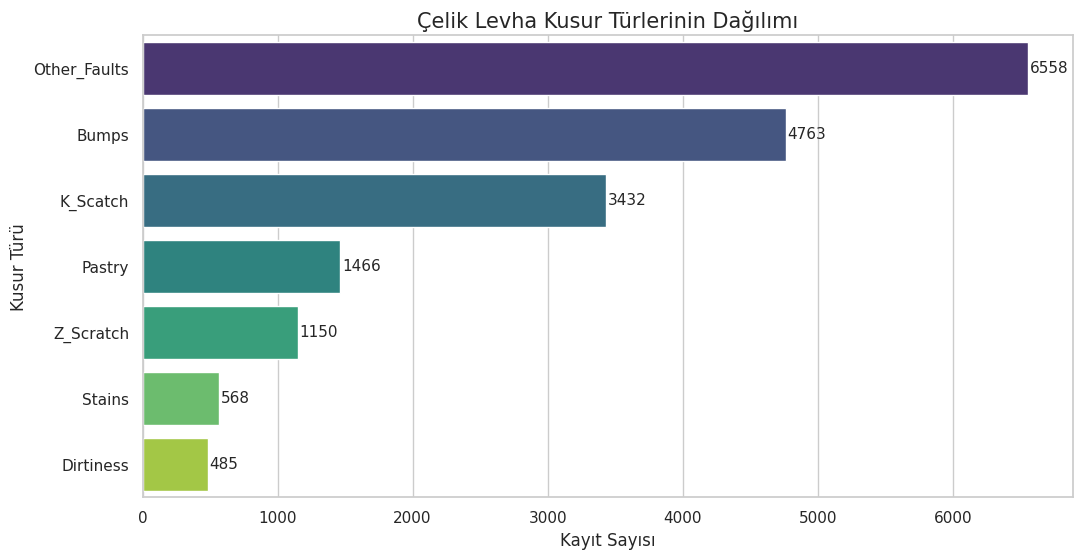

In [44]:
# Hedef sütunları tanımlama
target_cols = ['Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']

# Hedef değişkenlerin toplamlarını hesaplama
target_counts = train_df[target_cols].sum().sort_values(ascending=False)

# Grafik temasını ayarlama
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Çubuk grafik oluşturma
sns.barplot(x=target_counts.values, y=target_counts.index, hue=target_counts.index, palette="viridis", legend=False)

# Grafik başlıklarını ve etiketlerini düzenleme
plt.title('Çelik Levha Kusur Türlerinin Dağılımı', fontsize=15)
plt.xlabel('Kayıt Sayısı', fontsize=12)
plt.ylabel('Kusur Türü', fontsize=12)

# Grafik üzerinde değerleri gösterme
for i, v in enumerate(target_counts.values):
    plt.text(v + 10, i, str(int(v)), va='center', fontsize=11)
plt.savefig('kusur_dagilimi.png', dpi=300, bbox_inches='tight')
plt.show()

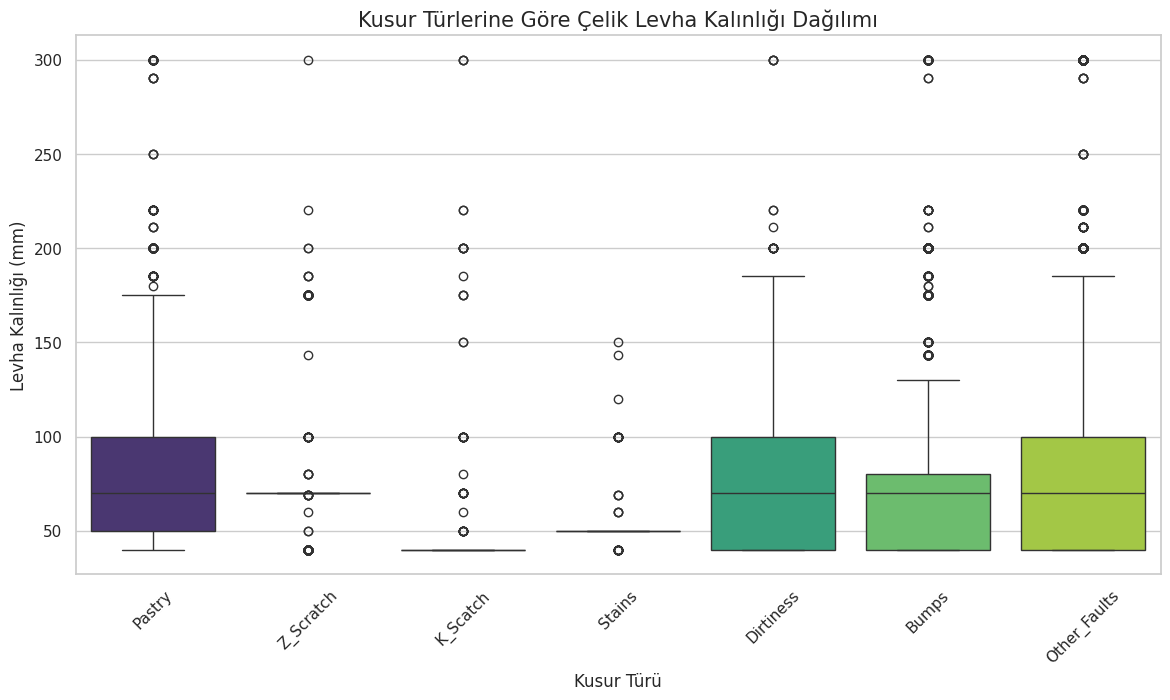

In [46]:
# Kusur türlerine göre çelik levha kalınlığı dağılımını inceleme
plt.figure(figsize=(14, 7))

# Analiz için veriyi "melt" ederek uzun formata getirme (Görselleştirme kolaylığı için)
melted_df = train_df.melt(id_vars=['Steel_Plate_Thickness'], 
                          value_vars=target_cols, 
                          var_name='Kusur_Türü', 
                          value_name='Hata_Var_Yok')

# Sadece hatanın olduğu (1) kayıtları filtreleme
melted_df = melted_df[melted_df['Hata_Var_Yok'] == 1]

# Kutu grafiği (Boxplot) oluşturma
sns.boxplot(data=melted_df, x='Kusur_Türü', y='Steel_Plate_Thickness', palette="viridis", hue='Kusur_Türü', legend=False)

# Grafik detaylarını düzenleme
plt.title('Kusur Türlerine Göre Çelik Levha Kalınlığı Dağılımı', fontsize=15)
plt.xlabel('Kusur Türü', fontsize=12)
plt.ylabel('Levha Kalınlığı (mm)', fontsize=12)
plt.xticks(rotation=45)
plt.savefig('kalinlik_kusur_dagilimi.png', dpi=300, bbox_inches='tight')
plt.show()

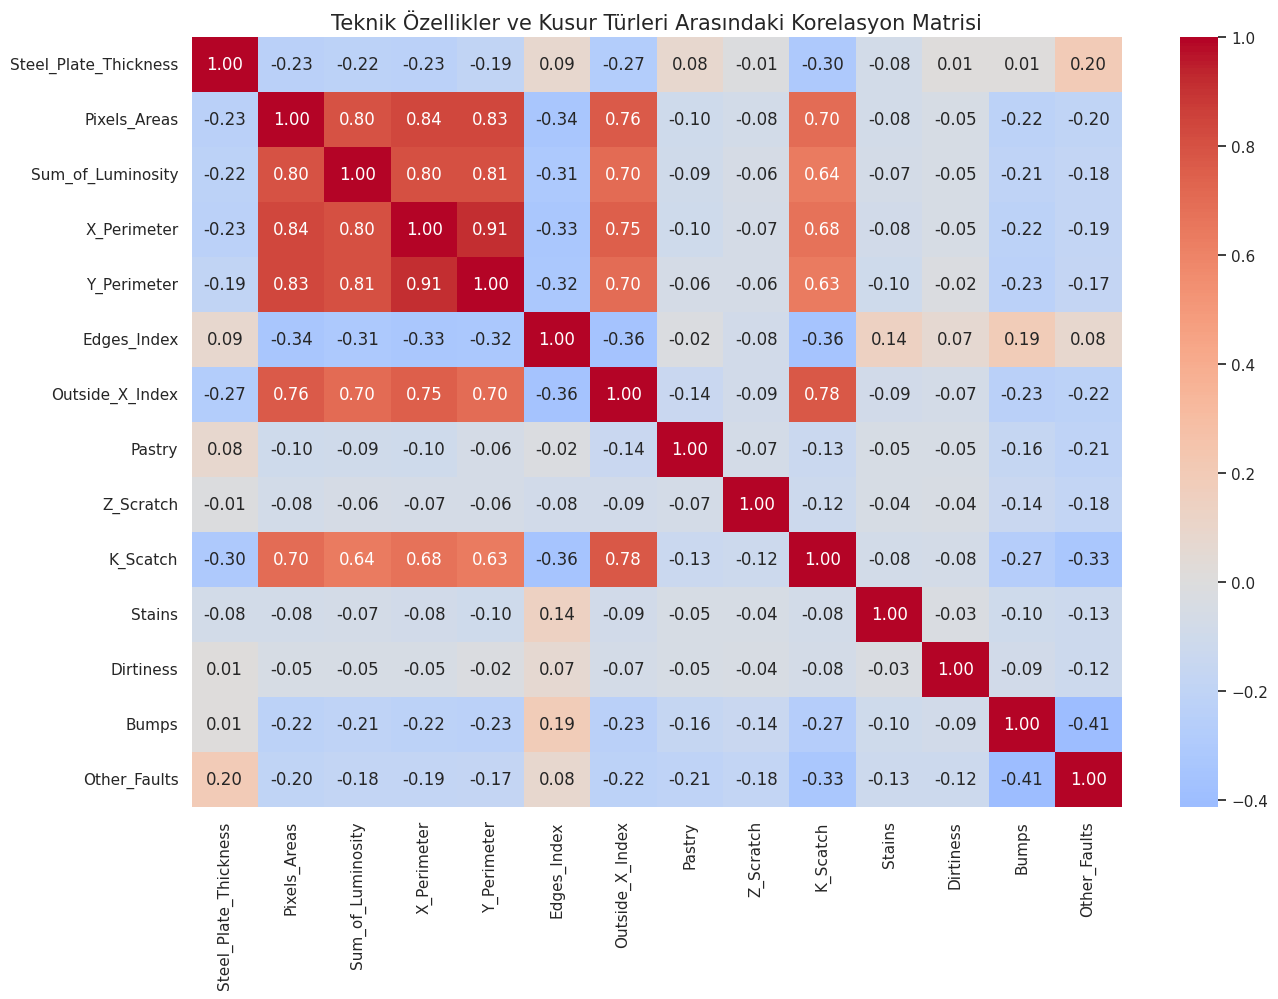

In [47]:

# Hedef değişkenleri ve bazı temel teknik özellikleri seçme
# Analizi boğmamak için en kritik teknik özellikleri listeye ekleme
features_to_check = [
    'Steel_Plate_Thickness', 'Pixels_Areas', 'Sum_of_Luminosity', 
    'X_Perimeter', 'Y_Perimeter', 'Edges_Index', 'Outside_X_Index'
]
target_cols = ['Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']

# Korelasyon matrisini hesaplama
corr_matrix = train_df[features_to_check + target_cols].corr()

# Isı haritasını çizme
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)

# Grafik başlığını düzenleme
plt.title('Teknik Özellikler ve Kusur Türleri Arasındaki Korelasyon Matrisi', fontsize=15)
plt.savefig('korelasyon_matrisi.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
# Yeni geometrik ve teknik özellikleri hesaplama

# Kusur genişliği ve yüksekliğini hesaplama
train_df['Defect_Width'] = train_df['X_Maximum'] - train_df['X_Minimum']
train_df['Defect_Height'] = train_df['Y_Maximum'] - train_df['Y_Minimum']

In [20]:
# En-Boy Oranı (Yatay uzunluk / Dikey uzunluk)
# Paydanın 0 olmaması için küçük bir tolerans ekleme
train_df['Aspect_Ratio'] = train_df['Defect_Width'] / (train_df['Defect_Height'] + 1e-5)

In [21]:
# Kusur Alanı / Çevre Oranı (Kusurun ne kadar "kompakt" olduğunu gösterir)
train_df['Area_Perimeter_Ratio'] = train_df['Pixels_Areas'] / (train_df['X_Perimeter'] + train_df['Y_Perimeter'] + 1e-5)

In [22]:
# Parlaklık Aralığı (Kontrast farkı)
train_df['Luminosity_Range'] = train_df['Maximum_of_Luminosity'] - train_df['Minimum_of_Luminosity']

In [23]:
# X ve Y eksenindeki yayılımın toplam parlaklığa oranı
train_df['Luminosity_Density'] = train_df['Sum_of_Luminosity'] / (train_df['Pixels_Areas'] + 1e-5)

In [24]:
# Aynı işlemleri test seti için de uygulama (Tutarlılık için şart)
test_df['Defect_Width'] = test_df['X_Maximum'] - test_df['X_Minimum']
test_df['Defect_Height'] = test_df['Y_Maximum'] - test_df['Y_Minimum']
test_df['Aspect_Ratio'] = test_df['Defect_Width'] / (test_df['Defect_Height'] + 1e-5)
test_df['Area_Perimeter_Ratio'] = test_df['Pixels_Areas'] / (test_df['X_Perimeter'] + test_df['Y_Perimeter'] + 1e-5)
test_df['Luminosity_Range'] = test_df['Maximum_of_Luminosity'] - test_df['Minimum_of_Luminosity']
test_df['Luminosity_Density'] = test_df['Sum_of_Luminosity'] / (test_df['Pixels_Areas'] + 1e-5)

In [25]:
# Yeni özellikleri kontrol etme
print("Yeni eklenen özellikler sonrası sütun sayısı:", train_df.shape[1])
print(train_df[['Aspect_Ratio', 'Luminosity_Range', 'Luminosity_Density']].head())

Yeni eklenen özellikler sonrası sütun sayısı: 41
   Aspect_Ratio  Luminosity_Range  Luminosity_Density
0      1.199998                27          142.124911
1      0.363636                41          102.720552
2      2.250000               112          115.155514
3      0.296296                20           15.247618
4      0.444444                29           92.573895


In [26]:
# Veriyi Eğitim ve Test Olarak Ayırma

from sklearn.model_selection import train_test_split

# Tahmin edilecek hedef sütunları belirleme
target_cols = ['Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']

In [27]:
# Girdi özelliklerini (X) ve hedef değişkenleri (y) ayırma
# 'id' sütununu ve hedef sütunları girdi setinden çıkarma
X = train_df.drop(columns=['id'] + target_cols)
y = train_df[target_cols]

In [28]:
# Veriyi eğitim ve doğrulama seti olarak bölme
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
# Bölünme sonrası boyutları kontrol etme
print(f"Eğitim seti boyutu: {X_train.shape}")
print(f"Doğrulama seti boyutu: {X_val.shape}")

Eğitim seti boyutu: (15375, 33)
Doğrulama seti boyutu: (3844, 33)


In [30]:
# Modeli Kurma
from xgboost import XGBClassifier
from sklearn.multiclass import OneVsRestClassifier

# XGBoost modelini tanımlama
# Çok etiketli (multi-label) yapıya uygun olması için OneVsRestClassifier içine alma
base_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    tree_method='hist' # Eğitim hızını artırmak için
)

model = OneVsRestClassifier(base_model)

# Modeli eğitme
model.fit(X_train, y_train)

print("Model eğitimi tamamlandı.")

Model eğitimi tamamlandı.


In [32]:
from sklearn.metrics import roc_auc_score, classification_report, accuracy_score

# Doğrulama seti üzerinde olasılık tahminleri yapma
y_pred_proba = model.predict_proba(X_val)
# Sınıf tahminleri yapma
y_pred = model.predict(X_val)

In [33]:
# AUC-ROC skorunu hesaplama 
# Her bir sütun için ayrı ayrı hesaplayıp ortalamasını alma
auc_score = roc_auc_score(y_val, y_pred_proba, multi_class='ovr', average='macro')

print(f"Genel AUC-ROC Skoru: {auc_score:.4f}")
print("-" * 30)

# Her sınıf için ayrıntılı performans raporu
print("Sınıf Bazlı Performans Raporu:")
print(classification_report(y_val, y_pred, target_names=target_cols))

Genel AUC-ROC Skoru: 0.8780
------------------------------
Sınıf Bazlı Performans Raporu:
              precision    recall  f1-score   support

      Pastry       0.52      0.14      0.22       301
   Z_Scratch       0.62      0.51      0.56       220
    K_Scatch       0.90      0.91      0.90       682
      Stains       0.61      0.77      0.68       100
   Dirtiness       0.44      0.13      0.20        85
       Bumps       0.52      0.35      0.42       926
Other_Faults       0.54      0.33      0.41      1349

   micro avg       0.64      0.45      0.53      3663
   macro avg       0.59      0.45      0.49      3663
weighted avg       0.61      0.45      0.50      3663
 samples avg       0.42      0.42      0.42      3663



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [34]:
# Özellik Önem Sıralamasını Kontrol Etme

# Özellik önem derecelerini alma (OneVsRest içindeki ilk model üzerinden)
feature_importances = pd.DataFrame({
    'Özellik': X_train.columns,
    'Önem': model.estimators_[0].feature_importances_
}).sort_values(by='Önem', ascending=False)

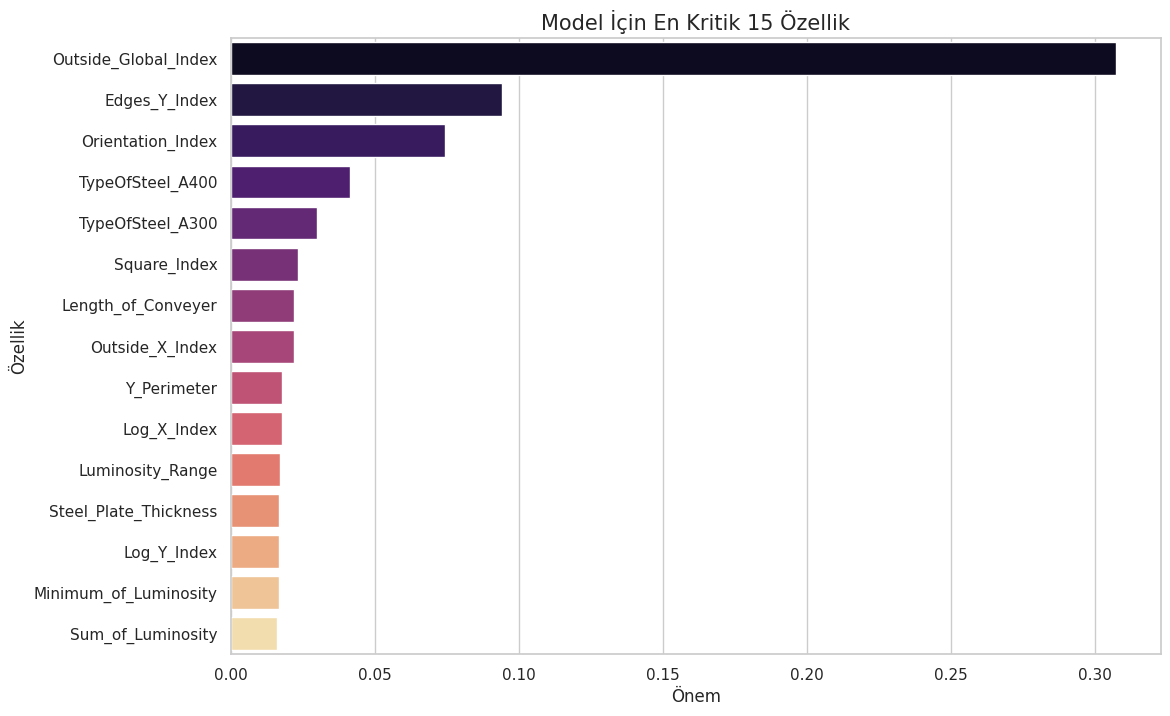

In [48]:
# Grafik oluşturma
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importances.head(15), x='Önem', y='Özellik', palette='magma', hue='Özellik', legend=False)
plt.title('Model İçin En Kritik 15 Özellik', fontsize=15)
plt.savefig('feature_importance_top15.png', dpi=300, bbox_inches='tight')
plt.show()

In [36]:
import optuna
from xgboost import XGBClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_auc_score

In [37]:
def objective(trial):
    # Modelin "dozaj" ayarlarını deneyeceğimiz aralıklar
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 1500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'tree_method': 'hist',
        'random_state': 42,
        'n_jobs': -1
    }
    
    # Modeli kurma ve eğitme
    base_model = XGBClassifier(**params)
    ovr_model = OneVsRestClassifier(base_model)
    ovr_model.fit(X_train, y_train)
    
    # Başarıyı doğrulama seti üzerinden ölçme
    preds = ovr_model.predict_proba(X_val)
    score = roc_auc_score(y_val, preds, multi_class='ovr', average='macro')
    
    return score

In [38]:
# Denemeleri başlatma
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20) # Zaman kazanmak için 20 deneme ile başlama

print("En iyi AUC Skoru:", study.best_value)
print("En iyi parametreler:", study.best_params)

[I 2026-05-03 09:38:05,848] A new study created in memory with name: no-name-4e0e6658-dc45-44fe-ad4e-693e7cedecb2
[I 2026-05-03 09:38:48,003] Trial 0 finished with value: 0.8776692811489955 and parameters: {'n_estimators': 1369, 'max_depth': 8, 'learning_rate': 0.042673720825821826, 'subsample': 0.9836285037159266, 'colsample_bytree': 0.7523670392681729, 'min_child_weight': 1}. Best is trial 0 with value: 0.8776692811489955.
[I 2026-05-03 09:39:30,249] Trial 1 finished with value: 0.875603796092352 and parameters: {'n_estimators': 1163, 'max_depth': 9, 'learning_rate': 0.04010248184286821, 'subsample': 0.7086121396223758, 'colsample_bytree': 0.9080969432812336, 'min_child_weight': 2}. Best is trial 0 with value: 0.8776692811489955.
[I 2026-05-03 09:39:48,293] Trial 2 finished with value: 0.881037875150956 and parameters: {'n_estimators': 976, 'max_depth': 5, 'learning_rate': 0.04438515143798271, 'subsample': 0.8257476507287755, 'colsample_bytree': 0.797331084650289, 'min_child_weight':

En iyi AUC Skoru: 0.8899090887724125
En iyi parametreler: {'n_estimators': 520, 'max_depth': 6, 'learning_rate': 0.010035855177324039, 'subsample': 0.5027964040485412, 'colsample_bytree': 0.6068283131222265, 'min_child_weight': 4}


In [39]:
# Optuna'dan gelen en iyi parametrelerle nihai modeli tanımlama
final_params = {
    'n_estimators': 520,
    'max_depth': 6,
    'learning_rate': 0.010035855177324039,
    'subsample': 0.5027964040485412,
    'colsample_bytree': 0.6068283131222265,
    'min_child_weight': 4,
    'tree_method': 'hist',
    'random_state': 42,
    'n_jobs': -1
}

final_base_model = XGBClassifier(**final_params)
final_model = OneVsRestClassifier(final_base_model)

In [40]:
# Modeli tüm eğitim verisi (X ve y) ile eğitme
final_model.fit(X, y)

OneVsRestClassifier(estimator=XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.6068283131222265,
                                            device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.010035855177324039,
                                            max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=6,
                                            max_leaves=None, min_child_weight=4,
                                            missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=520, n_jobs=-1,
                                            num_parallel_tree=None, ...))

In [41]:
# Test setinden 'id' sütununu çıkararak tahmin yapma
X_test = test_df.drop(columns=['id'])
test_preds_proba = final_model.predict_proba(X_test)

# Tahminleri Kaggle formatına getirme
submission = pd.DataFrame(test_preds_proba, columns=target_cols)
submission.insert(0, 'id', test_df['id'])

# Sonuçları kaydetme
submission.to_csv('submission.csv', index=False)

print("Nihai model eğitildi ve 'submission.csv' dosyası hazırlandı.")
print(submission.head())

Nihai model eğitildi ve 'submission.csv' dosyası hazırlandı.
      id    Pastry  Z_Scratch  K_Scatch    Stains  Dirtiness     Bumps  \
0  19219  0.472667   0.002912  0.003209  0.000342   0.014045  0.185256   
1  19220  0.287433   0.020896  0.009555  0.000480   0.179372  0.173980   
2  19221  0.003286   0.027880  0.041078  0.000799   0.007488  0.335530   
3  19222  0.159851   0.002752  0.001773  0.001528   0.012659  0.412183   
4  19223  0.003121   0.002834  0.001927  0.002959   0.005911  0.598028   

   Other_Faults  
0      0.363816  
1      0.330095  
2      0.463137  
3      0.402240  
4      0.381741  


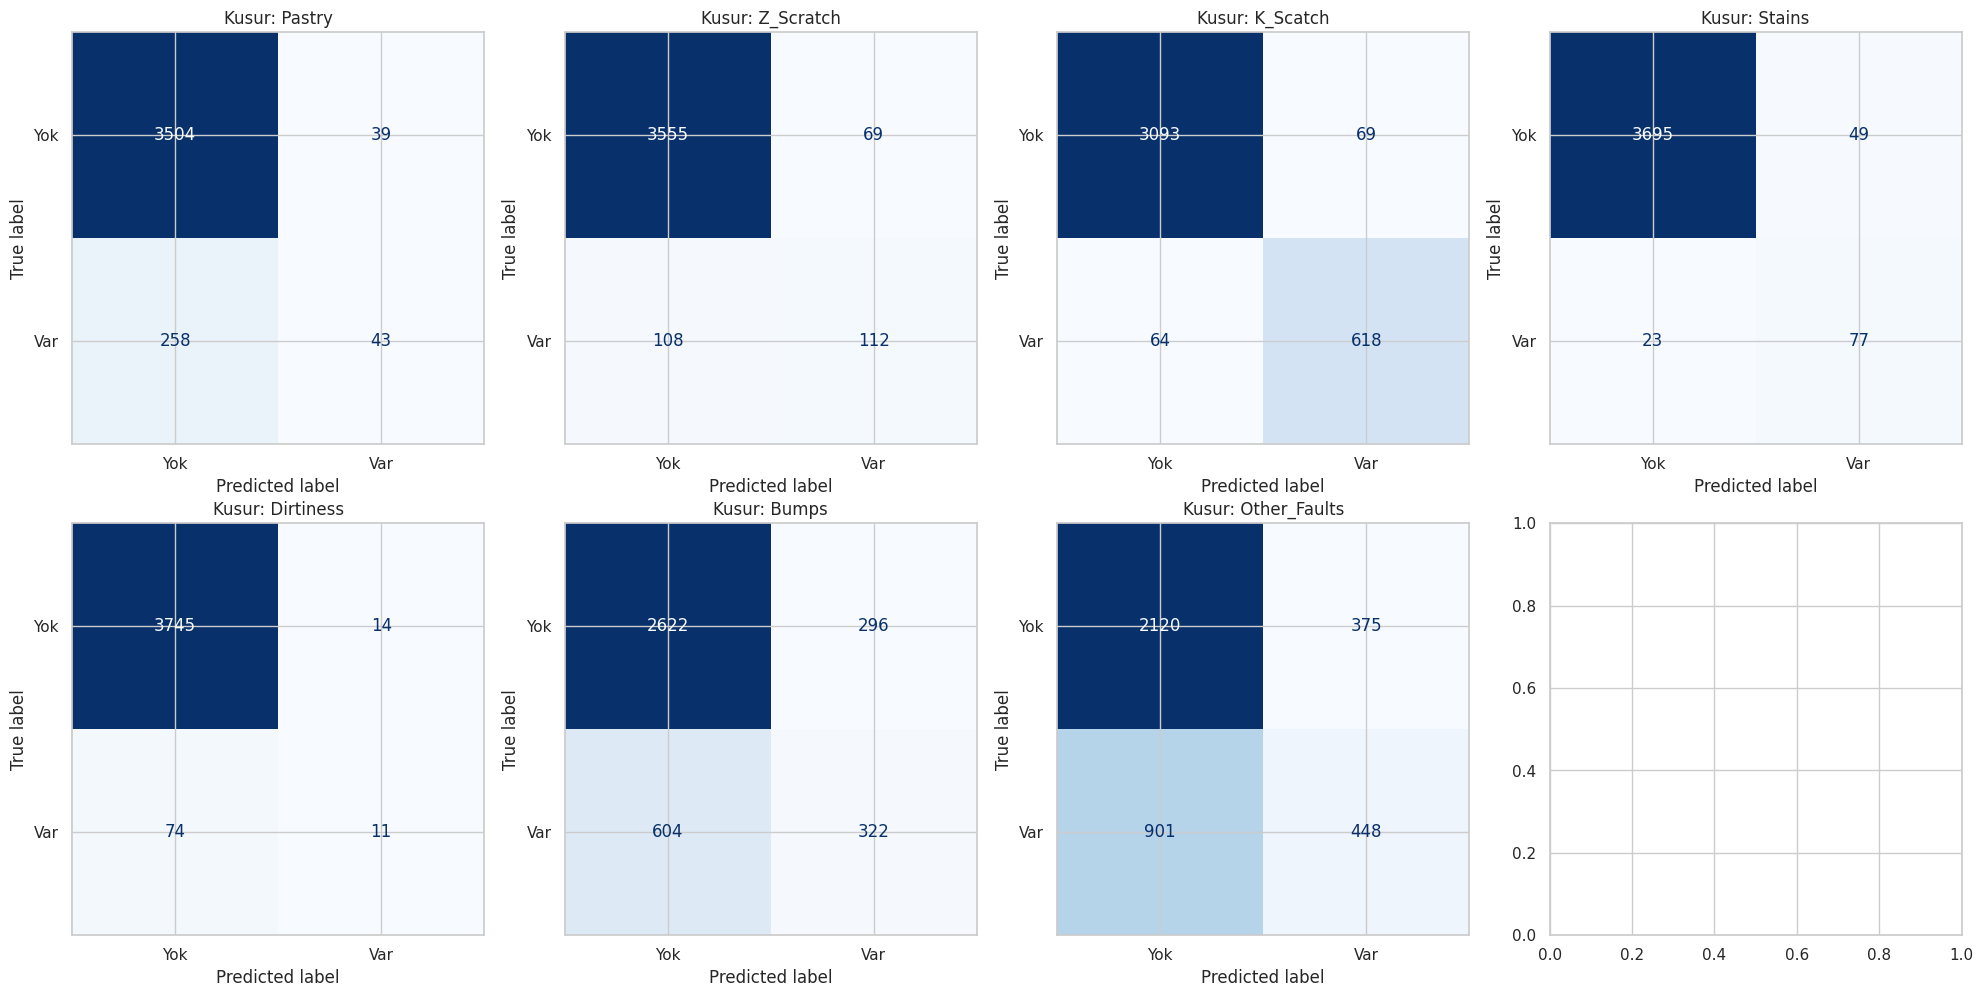

In [49]:
# Karışıklık Matrisi (Confusion Matrix)
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay

# Her bir kusur türü için ayrı bir karışıklık matrisi oluşturma
mcm = multilabel_confusion_matrix(y_val, y_pred)

# Görselleştirme için 2x4'lük bir grafik alanı hazırlama
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()

for i, (matrix, name) in enumerate(zip(mcm, target_cols)):
    disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=['Yok', 'Var'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'Kusur: {name}')

# Fazla olan son boş grafiği kapatma
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

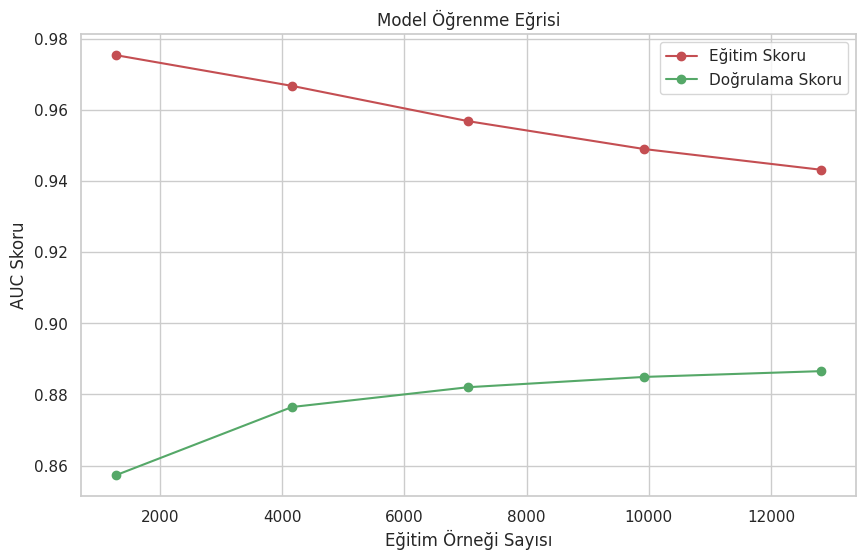

In [50]:
# Öğrenme Eğrileri (Learning Curves)
from sklearn.model_selection import learning_curve

# Öğrenme eğrisini hesaplama
train_sizes, train_scores, test_scores = learning_curve(
    final_model, X, y, cv=3, scoring='roc_auc', n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Skorların ortalamasını alma
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# Grafiği çizme
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Eğitim Skoru')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='Doğrulama Skoru')
plt.title('Model Öğrenme Eğrisi')
plt.xlabel('Eğitim Örneği Sayısı')
plt.ylabel('AUC Skoru')
plt.legend(loc='best')
plt.grid(True)
plt.savefig('learning_curve.png', dpi=300, bbox_inches='tight')
plt.show()

## 🧱 Veri Seti Özeti

* Çoklu sensör tabanlı yüzey ölçümleri
* Geometrik özellikler
* Parlaklık değerleri
* Global yüzey indeksleri
* Çok sınıflı kusur etiketleri

## 🔬 Veri Ön İşleme Süreci

### Uygulanan Adımlar:

* Eksik veri kontrolü
* Feature scaling
* Yeni özellik üretimi:

  * Aspect Ratio
  * Luminosity Range
  * Shape Complexity
* Class distribution analizi
* Stratified validation

## 🛠️ Kullanılan Teknolojiler

* Python
* Pandas
* NumPy
* Scikit-learn
* XGBoost
* Optuna
* Matplotlib
* Seaborn
* Streamlit

## ⚙️ Model Optimizasyonu

### Optuna ile optimize edilen parametreler:

| Parametre        | Nihai Değer     |
| ---------------- | --------------- |
| Learning Rate    | 0.0100          |
| Max Depth        | 6               |
| N-Estimators     | 520             |
| Subsample        | 0.5027          |
| Colsample_bytree | Optimize edildi |
| Gamma            | Optimize edildi |

## 📊 Performans Analizi

### Güçlü Yönler:

* Dengeli öğrenme
* Güçlü genelleme
* Yüksek AUC
* Endüstriyel uygulanabilirlik

### Zayıf Yönler:

* Benzer kusurlarda sınıf karışımı
* Nadir kusurlarda daha düşük recall


In [ ]:
# Grafikleri kaydetme

import matplotlib.pyplot as plt

def save_all_reports():
    # Özellik Önem Grafiği
    # Bu satırı ilgili grafik kodunun hemen altına ekle
    plt.figure(1) # Hangi figür olduğu belliyse
    plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
    
    # 2. Öğrenme Eğrisi
    plt.figure(2)
    plt.savefig('learning_curve.png', dpi=300, bbox_inches='tight')
    
    # 3. Karışıklık Matrisi
    plt.figure(3)
    plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
    
    print("✅ Tüm rapor grafikleri yüksek çözünürlükte (300 DPI) kaydedildi.")

# Fonksiyonu çağır
save_all_reports()

In [52]:
import joblib

# Sadece modeli mühürlememiz yeterli
joblib.dump(final_model, 'optimized_xgboost_model.pkl')
print("✅ Nihai model 'optimized_xgboost_model.pkl' olarak mühürlendi.")

✅ Nihai model 'optimized_xgboost_model.pkl' olarak mühürlendi.
